<a href="https://colab.research.google.com/github/annjgs/Fisica-Computacionalo/blob/Taller-6/tarea1parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1**.IMPLEMENTAR LA SEGUNDA DERIVADA NUMÉRICA EN C++

In [ ]:

%%writefile programa.cpp
#include <iostream>
#include <cmath>
#include <functional>

// f(x) = x^3
double miFunciondeprueba(double x) {
    return std::pow(x, 3);
}

double segundaDerivada(std::function<double(double)> f, double x, double h = 0.001) {
    return (f(x + h) - 2 * f(x) + f(x - h)) / (h * h);
}

int main() {
    double punto = 2.0;
    double resultado = segundaDerivada(miFunciondeprueba, punto);

    std::cout << "La segunda derivada en x = " << punto << " es: " << resultado << std::endl;
    return 0;
}



Overwriting programa.cpp


In [ ]:
!g++ programa.cpp -o programa
!./programa

La segunda derivada en x = 2 es: 12


**2.** SEGUNDA DERIVADA DE UNA FUNCIÓN COS, Y SU RESPECTIVA GRÁFICA

In [ ]:
%%writefile programa_derivada.cpp
#include <iostream>
#include <cmath>
#include <fstream>
#include <functional>

//  función trigonometrica cos(x)
double funcionCos(double x) {
    return std::cos(x);
}

// segunda derivada: -cos(x)
double derivadaExacta(double x) {
    return -std::cos(x);
}

// Segunda derivada numérica
double segundaDerivadaNumerica(std::function<double(double)> f, double x, double h = 0.1) {
    return (f(x + h) - 2 * f(x) + f(x - h)) / (h * h);
}

int main() {
    // Se  abre un archivo para guardar los datos y graficarlos luego en python
    std::ofstream archivo("datos.txt");

    double h = 0.1;
    double pi = M_PI;

    for (double x = 0; x <= 2 * pi; x += 0.05) {
        double original = funcionCos(x);
        double aprox = segundaDerivadaNumerica(funcionCos, x, h);
        double exacta = derivadaExacta(x);
        double error = std::abs(exacta - aprox); // Error absoluto


        archivo << x << " " << original << " " << aprox << " " << exacta << " " << error << "\n";
    }

    archivo.close();
    std::cout << "Datos calculados" << std::endl;
    return 0;
}

Writing programa_derivada.cpp


In [ ]:
!g++ programa_derivada.cpp -o programa_derivada
!./programa_derivada

cc1plus: fatal error: programa_derivada.cpp: No such file or directory
compilation terminated.
/bin/bash: line 1: ./programa_derivada: No such file or directory


/tmp/ipykernel_2575/3733504407.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


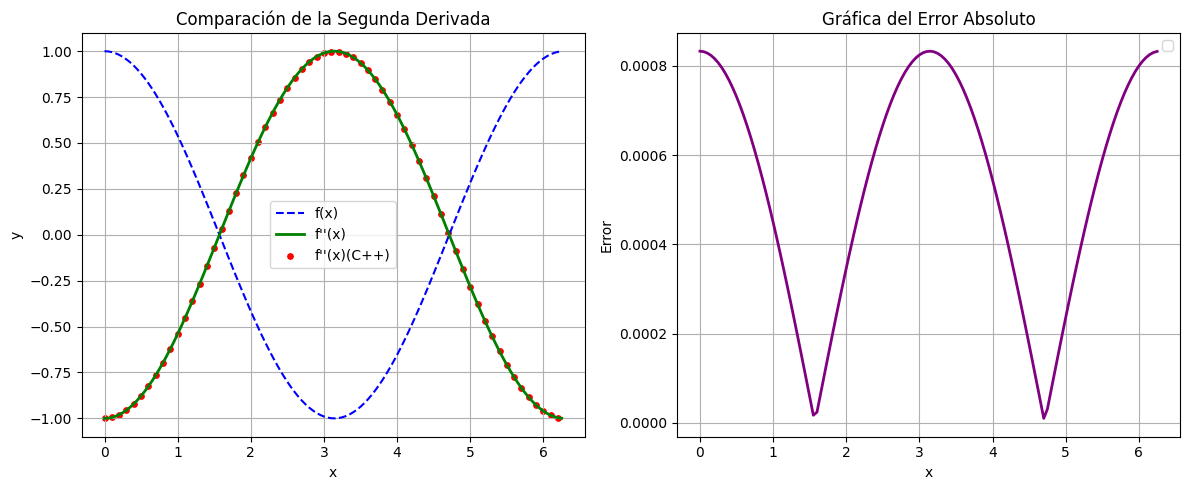

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Aquí se lee los datos del código anterior
datos = np.loadtxt('datos.txt')
x = datos[:, 0]
original = datos[:, 1]
aprox = datos[:, 2]
exacta = datos[:, 3]
error = datos[:, 4]

# Primera gráfica
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x, original, label='f(x)', color='blue', linestyle='--')
plt.plot(x, exacta, label="f''(x)", color='green', linewidth=2)
plt.scatter(x[::2], aprox[::2], label="f''(x)(C++)", color='red', marker='o', s=15)
plt.title('Comparación de la Segunda Derivada')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Segunda gráfica
plt.subplot(1, 2, 2)
plt.plot(x, error, color='purple', linewidth=2)
plt.title('Gráfica del Error Absoluto')
plt.xlabel('x')
plt.ylabel('Error')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**3** CÁLCULO DE h vs Error

In [3]:
%%writefile programa_tarea.cpp
#include <iostream>
#include <cmath>
#include <fstream>

using namespace std;

// f(x) = cos(x)
double funcion_coseno(double x) {
    return cos(x);
}

// Segunda derivada
double derivada_exacta(double x) {
    return -cos(x);
}

int main() {
    // Creamos el archivo para guardar los datos de la gráfica
    ofstream mi_archivo("datos_h.txt");

    //  x = 1.0
    double x = 1.0;
    double valor_real = derivada_exacta(x);


    double mis_valores_h[10] = {0.5, 0.3, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001};

    cout << "--- CALCULO DE ERRORES ---" << endl;

    for (int i = 0; i < 10; i++) {
        double h = mis_valores_h[i];

        double derivada_numerica = (funcion_coseno(x + h) - 2 * funcion_coseno(x) + funcion_coseno(x - h)) / (h * h);

        double error = abs(valor_real - derivada_numerica);

        mi_archivo << h << " " << error << endl;
    }

    mi_archivo.close();
    cout << "Archivo Guardado" << endl;

    return 0;
}

Writing programa_tarea.cpp


In [4]:
!g++ programa_tarea.cpp -o programa_tarea
!./programa_tarea

--- CALCULO DE ERRORES ---
Archivo Guardado


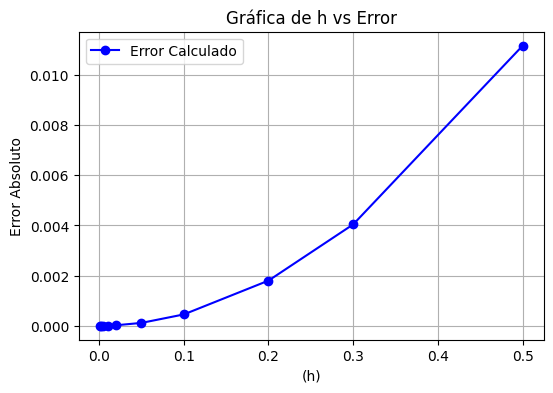

Datos obtenidos:
h = 0.5 -> Error = 0.0111629000
h = 0.3 -> Error = 0.0040401300
h = 0.2 -> Error = 0.0017986100
h = 0.1 -> Error = 0.0004501020
h = 0.05 -> Error = 0.0001125540
h = 0.02 -> Error = 0.0000180098
h = 0.01 -> Error = 0.0000045025
h = 0.005 -> Error = 0.0000011256
h = 0.002 -> Error = 0.0000001801
h = 0.001 -> Error = 0.0000000450


In [5]:
import matplotlib.pyplot as plt
import numpy as np

datos = np.loadtxt('datos_h.txt')
h = datos[:, 0]
error = datos[:, 1]

# gráfica de h vs Error
plt.figure(figsize=(6, 4))
plt.plot(h, error, marker='o', color='blue', label='Error Calculado')

plt.title('Gráfica de h vs Error')
plt.xlabel('(h)')
plt.ylabel('Error Absoluto')
plt.grid(True)
plt.legend()
plt.show()

print("Datos obtenidos:")
for i in range(len(h)):
    print(f"h = {h[i]} -> Error = {error[i]:.10f}")